In [1]:
import os
os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'

import tensorflow as tf

# 메모리 성장 모드 — 필요한 만큼만 점진적으로 할당
gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

print("TF:", tf.__version__)
print("GPU:", gpus)

I0000 00:00:1780046329.813275    1723 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TF: 2.21.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# 모듈 불러오기

import os, random
import numpy as np
import tensorflow as tf
import koreanize_matplotlib
import matplotlib.pyplot as plt

In [3]:
# 랜덤시드 고정으로 재현성 확보하기
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [4]:
# 이미지 크기가 278*278임
IMG_HEIGHT = 278
IMG_WIDTH = 278

BATCH_SIZE = 128 # 하이퍼파라미터 설정시 변경

In [5]:
# 데이터셋 불러오기
import pandas as pd
path = "/root/data/comnist/"
train = pd.read_csv(os.path.join(path, "train.csv"))
test = pd.read_csv(os.path.join(path, "test.csv"))
print(f"\n데이터 로드 성공! Train: {train.shape}")
print(f"\n데이터 로드 성공! Test: {test.shape}")


데이터 로드 성공! Train: (10260, 2)

데이터 로드 성공! Test: (2565, 1)


In [6]:
train.head()

,filename,label
0,train/N/58c5a7ea13c33.png,N
1,train/X/58c3f99b763e7.png,X
2,train/Q/59b401384e112.png,Q
3,train/Y/58bf25283cb17.png,Y
4,train/X/58c70784d485a.png,X


In [7]:
test.head()

,filename
0,test/58bed95374e57.png
1,test/58bf1977b67bf.png
2,test/58bc3b7403476.png
3,test/58c3fa2e4df1a.png
4,test/58ac474e1af3b.png


In [8]:
TRAIN_DATA_PATH = '/root/data/comnist/images/train/'
TEST_DATA_PATH = '/root/data/comnist/images/test/'

In [9]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DATA_PATH,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    color_mode="rgba" # alpha 채널 정보 포함
)

Found 5616 files belonging to 26 classes.
Using 4493 files for training.


I0000 00:00:1780046892.555873    1723 gpu_process_state.cc:208] Using CUDA malloc Async allocator for GPU: 0
I0000 00:00:1780046892.558299    1723 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 79191 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-80GB, pci bus id: 0000:20:1c.0, compute capability: 8.0


In [10]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DATA_PATH,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    color_mode="rgba" # alpha 채널 정보 포함
)

Found 5616 files belonging to 26 classes.
Using 1123 files for validation.


In [11]:
class_names = train_ds.class_names
num_classes = len(class_names)
print(f"클래스 개수: {num_classes}, 라벨: {class_names}")

클래스 개수: 26, 라벨: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


In [12]:
# 투명 배경을 흰색으로 바꾸는 함수 정의
def convert_transparent_to_white_bg_gray(image, label):
    # 정규화 (0~255 -> 0~1)
    image = tf.cast(image, tf.float32) / 255.0

    # 채널 분리
    rgb = image[..., :3]    # 색상 정보 (검은 글씨)
    alpha = image[..., 3:]  # 투명도 정보 (글씨 부분은 1, 배경은 0)

    # 투명한 배경을 흰색(1.0)으로 채우기
    # 결과 = (글씨 색 * 투명도) + (흰색 * (1 - 투명도))
    white_bg = tf.ones_like(rgb)
    new_image = (rgb * alpha) + (white_bg * (1.0 - alpha))

    # RGB -> Grayscale 변환
    # 채널이 3개에서 1개로 줄어듭니다.
    gray_image = tf.image.rgb_to_grayscale(new_image)

    return gray_image, label

In [13]:
train_ds = train_ds.map(convert_transparent_to_white_bg_gray)
val_ds = val_ds.map(convert_transparent_to_white_bg_gray)

In [14]:
# 성능 최적화
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("데이터 전처리 완료")

데이터 전처리 완료


W0000 00:00:1780047312.233866    3010 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


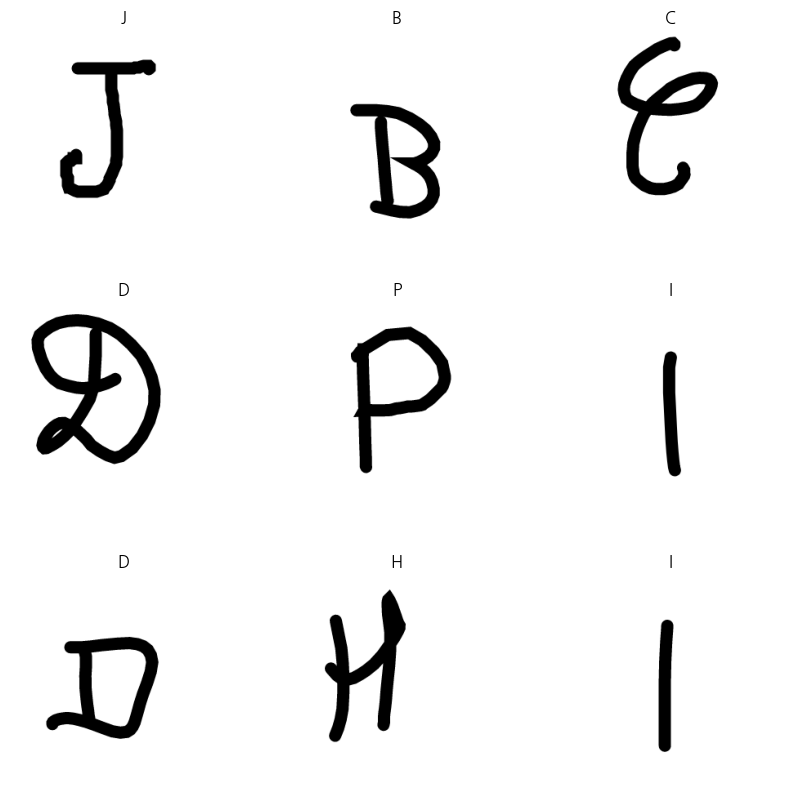

In [15]:
# 학습 데이터셋에서 배치를 하나 가져옵니다
for images, labels in train_ds.take(1):
    plt.figure(figsize=(10, 10))
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        # 이미지가 정규화(0~1) 되어있으므로 바로 출력 가능
        plt.imshow(images[i].numpy(), cmap='gray')
        plt.title(class_names[labels[i]])
        plt.axis("off")
    plt.show()
    break

In [16]:
data_aug = tf.keras.Sequential([
    # 좌우 반전 (알파벳은 b/d 처럼 의미가 달라질 수 있어 주의 필요, 포트홀엔 필수)
    # tf.keras.layers.RandomFlip("horizontal", seed=SEED),

    # 무작위 회전 (약 20% 범위 내에서 비틀어 보기)
    tf.keras.layers.RandomRotation(0.2, seed=SEED),

    # 무작위 확대/축소 (약 20% 범위 내에서 멀리서/가까이서 보기)
    tf.keras.layers.RandomZoom(0.2, seed=SEED),
])

In [17]:
inputs = tf.keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 1))

x = data_aug(inputs)

x = tf.keras.layers.Conv2D(32, (3, 3), padding="same")(x)
x = tf.keras.layers.ReLU()(x)
x = tf.keras.layers.MaxPooling2D((2, 2))(x)

x = tf.keras.layers.Conv2D(64, (3, 3), padding="same")(x)
x = tf.keras.layers.ReLU()(x)
x = tf.keras.layers.MaxPooling2D((2, 2))(x)

x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dense(128)(x)
x = tf.keras.layers.ReLU()(x)

# 출력층 변경: num_classes (알파벳 개수만큼)
outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs, name="alphabet_cnn_baseline")

In [18]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=["accuracy"],
)

In [19]:
model.summary()

Model: "alphabet_cnn_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 278, 278, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 278, 278, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 278, 278, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 278, 278, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 139, 139, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 139, 139, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 139, 139, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 69, 69, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 304704)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    39,002,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 26)             │         3,354 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,024,410 (148.87 MB)

 Trainable params: 39,024,410 (148.87 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    )
]

In [27]:
# 제미나이

# 하이퍼파라미터
SEED = 42
IMG_HEIGHT = 278 # 실제 사용하는 이미지 크기에 맞게 변경하세요
IMG_WIDTH = 278
num_classes = 26 # 알파벳 개수 (대소문자 통합 등 조건에 맞게 변경)

# 1. 개선된 데이터 증강 (Data Augmentation)
data_aug = tf.keras.Sequential([
    # 회전 범위를 0.05 (약 18도) ~ 최대 0.1 (약 36도) 수준으로 제한해야 글자의 의미가 변하지 않습니다.
    tf.keras.layers.RandomRotation(0.05, seed=SEED),
    tf.keras.layers.RandomZoom(0.1, seed=SEED),      # 확대/축소도 10% 내외로 제한
    tf.keras.layers.RandomTranslation(0.1, 0.1, seed=SEED) # 상하좌우 10% 이동 추가 (매우 효과적)
], name="data_augmentation")

inputs = tf.keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 1))

# (선택) 만약 전처리 단계에서 0~1 사이로 정규화(/255.0)를 안 하셨다면 아래 주석을 푸세요.
# x = tf.keras.layers.Rescaling(1./255)(inputs) 
# x = data_aug(x)

x = data_aug(inputs)

# 2. VGG 스타일의 깊은 합성곱 신경망 (Convolutional Block 1)
x = tf.keras.layers.Conv2D(32, (3, 3), padding="same")(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.ReLU()(x)
x = tf.keras.layers.Conv2D(32, (3, 3), padding="same")(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.ReLU()(x)
x = tf.keras.layers.MaxPooling2D((2, 2))(x)
x = tf.keras.layers.Dropout(0.25)(x) # 과적합 방지

# Convolutional Block 2
x = tf.keras.layers.Conv2D(64, (3, 3), padding="same")(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.ReLU()(x)
x = tf.keras.layers.Conv2D(64, (3, 3), padding="same")(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.ReLU()(x)
x = tf.keras.layers.MaxPooling2D((2, 2))(x)
x = tf.keras.layers.Dropout(0.25)(x)

# Convolutional Block 3 (옵션: 이미지가 28x28처럼 작다면 필터 128짜리 Conv2D는 1개만 넣어도 충분)
x = tf.keras.layers.Conv2D(128, (3, 3), padding="same")(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.ReLU()(x)
x = tf.keras.layers.MaxPooling2D((2, 2))(x)
x = tf.keras.layers.Dropout(0.25)(x)

# Fully Connected Layer (분류기)
x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dense(256)(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.ReLU()(x)
x = tf.keras.layers.Dropout(0.5)(x)

# 출력층
outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs, name="alphabet_cnn_advanced")

# 3. 옵티마이저 학습률 명시적 설정
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=["accuracy"],
)

model.summary()

# 4. 콜백(Callbacks) 설정 (Model.fit() 할 때 반드시 callbacks 파라미터로 넣어주세요)
callbacks = [
    # 검증 정확도(val_accuracy)가 10번의 에포크 동안 안 오르면 조기 종료하고 최고 성능 가중치 복원
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True),
    # 검증 손실(val_loss)이 3번의 에포크 동안 안 떨어지면 학습률을 절반으로 감소시킴 (미세조정)
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5, verbose=1)
]

Model: "alphabet_cnn_advanced"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 278, 278, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 278, 278, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 278, 278, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 278, 278, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 278, 278, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 278, 278, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 278, 278, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 278, 278, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 139, 139, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 139, 139, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 139, 139, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 139, 139, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 139, 139, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 139, 139, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 139, 139, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_6 (ReLU)                  │ (None, 139, 139, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 69, 69, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 69, 69, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 69, 69, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 69, 69, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_7 (ReLU)                  │ (None, 69, 69, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 34, 34, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 38,027,898 (145.06 MB)

 Trainable params: 38,026,746 (145.06 MB)

 Non-trainable params: 1,152 (4.50 KB)

In [33]:
# 클로드

data_aug = tf.keras.Sequential([
    # 좌우 반전은 알파벳에서 금지 (b↔d, p↔q 문제)
    # tf.keras.layers.RandomFlip("horizontal", seed=SEED),

    tf.keras.layers.RandomRotation(0.1, seed=SEED),          # 너무 크면 6/9, n/u 혼동
    tf.keras.layers.RandomZoom(0.15, seed=SEED),
    tf.keras.layers.RandomTranslation(0.1, 0.1, seed=SEED),  # 위치 변화 대응
    tf.keras.layers.RandomContrast(0.2, seed=SEED),          # 글씨 두께/대비 변화 대응
], name="data_augmentation")


# ============================
# 2. Conv Block 헬퍼 함수
# ============================
def conv_block(x, filters, dropout_rate=0.25):
    x = tf.keras.layers.Conv2D(filters, (3, 3), padding="same", use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)

    x = tf.keras.layers.Conv2D(filters, (3, 3), padding="same", use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)

    x = tf.keras.layers.MaxPooling2D((2, 2))(x)
    x = tf.keras.layers.Dropout(dropout_rate)(x)
    return x


# ============================
# 3. 모델 구성
# ============================
inputs = tf.keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 1))

# (이미 0~1 정규화 했다면 Rescaling 생략, 안했으면 주석 해제)
# x = tf.keras.layers.Rescaling(1./255)(inputs)
x = data_aug(inputs)

x = conv_block(x, 32, dropout_rate=0.25)   # -> 1/2
x = conv_block(x, 64, dropout_rate=0.25)   # -> 1/4
x = conv_block(x, 128, dropout_rate=0.3)   # -> 1/8

# Flatten 대신 GAP (파라미터 적고 과적합 ↓)
x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dense(256, use_bias=False)(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.ReLU()(x)
x = tf.keras.layers.Dropout(0.5)(x)

outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs, name="alphabet_cnn_improved")


# ============================
# 4. 컴파일 (Label Smoothing 적용)
# ============================
# sparse 라벨이면 SparseCategoricalCrossentropy는 label_smoothing 지원 X
# -> one-hot으로 바꿔서 CategoricalCrossentropy 쓰는 게 베스트
# 여기선 sparse 유지하고 싶다면 그대로 사용
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=["accuracy"],
)

model.summary()


# ============================
# 5. 콜백 (성능 끌어올리는 핵심)
# ============================
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=10,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        verbose=1,
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "best_model.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1,
    ),
]

Model: "alphabet_cnn_improved"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 278, 278, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 278, 278, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 278, 278, 32)   │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 278, 278, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_9 (ReLU)                  │ (None, 278, 278, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 278, 278, 32)   │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 278, 278, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_10 (ReLU)                 │ (None, 278, 278, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 139, 139, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 139, 139, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 139, 139, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 139, 139, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_11 (ReLU)                 │ (None, 139, 139, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 139, 139, 64)   │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 139, 139, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_12 (ReLU)                 │ (None, 139, 139, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 69, 69, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 69, 69, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 69, 69, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 69, 69, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_13 (ReLU)                 │ (None, 69, 69, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 69, 69, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 328,250 (1.25 MB)

 Trainable params: 326,842 (1.25 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [34]:
import time
import datetime

start_time = time.time()

# --- 학습 코드 -------------
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    batch_size=BATCH_SIZE,
    callbacks=[callbacks],
    verbose=1
)
# -------------------------
end_time = time.time()
execution_time = end_time - start_time

# 시:분:초 형태로 자동 변환
str_time = str(datetime.timedelta(seconds=execution_time))
print(f"총 학습 소요 시간: {str_time}")

Epoch 1/100


E0000 00:00:1780050971.835507    1723 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/alphabet_cnn_improved_1/dropout_4_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.1204 - loss: 3.0746
Epoch 1: val_accuracy improved from None to 0.06857, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
36/36 ━━━━━━━━━━━━━━━━━━━━ 16s 287ms/step - accuracy: 0.1660 - loss: 2.7753 - val_accuracy: 0.0686 - val_loss: 3.0465 - learning_rate: 0.0010
Epoch 2/100
35/36 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - accuracy: 0.2393 - loss: 2.3899
Epoch 2: val_accuracy did not improve from 0.06857
36/36 ━━━━━━━━━━━━━━━━━━━━ 9s 246ms/step - accuracy: 0.2377 - loss: 2.3557 - val_accuracy: 0.0686 - val_loss: 2.9533 - learning_rate: 0.0010
Epoch 3/100
35/36 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - accuracy: 0.2560 - loss: 2.2505
Epoch 3: val_accuracy did not improve from 0.06857
36/36 ━━━━━━━━━━━━━━━━━━━━ 9s 246ms/step - accuracy: 0.2571 - loss: 2.2282 - val_accuracy: 0.0686 - val_loss: 2.9882 - learning_rate: 0.0010
Epoch 4/100
35/36 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - accuracy: 0.2758 - loss: 2.1669


In [35]:
test_loss, test_acc = model.evaluate(val_ds, verbose=0)
print(f"\n[Test] loss={test_loss:.4f}, acc={test_acc:.4f}")


[Test] loss=2.1245, acc=0.3277


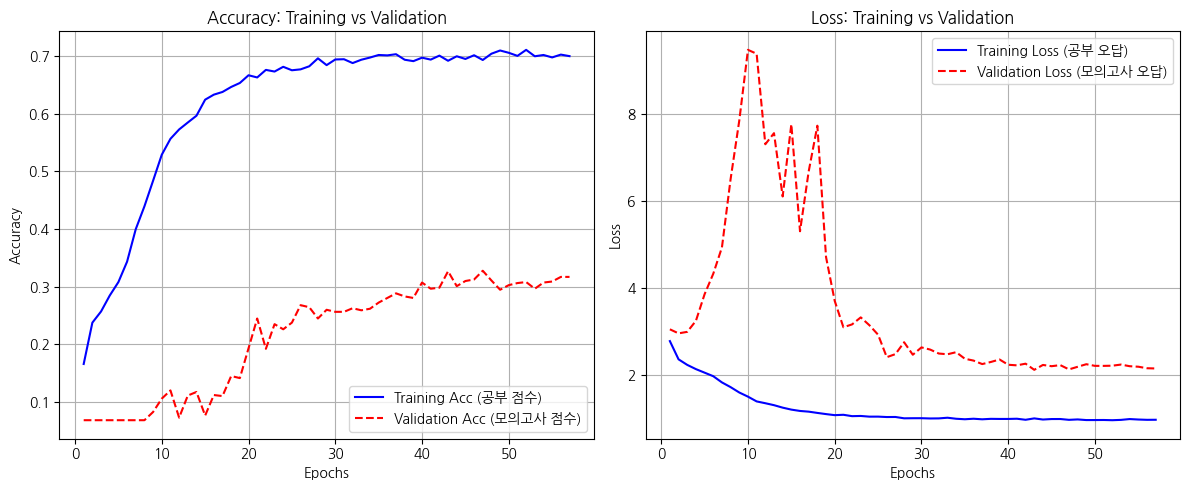

In [36]:
import matplotlib.pyplot as plt

def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    # [왼쪽] 정확도(Accuracy) 그래프
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'b-', label='Training Acc (공부 점수)')
    plt.plot(epochs, val_acc, 'r--', label='Validation Acc (모의고사 점수)')
    plt.title('Accuracy: Training vs Validation')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # [오른쪽] 손실(Loss) 그래프
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b-', label='Training Loss (공부 오답)')
    plt.plot(epochs, val_loss, 'r--', label='Validation Loss (모의고사 오답)')
    plt.title('Loss: Training vs Validation')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# 그래프 출력
plot_history(history)

In [37]:
# 테스트 데이터로 예측하기

import pandas as pd
import tensorflow as tf
import os

# 1. 테스트용 전처리 함수 (학습 때와 똑같이)
def load_and_preprocess_test_image(file_path):
    # 이미지 읽기
    img = tf.io.read_file(file_path)
    img = tf.io.decode_png(img, channels=4) # RGBA

    # 크기 조정
    img = tf.image.resize(img, [IMG_HEIGHT, IMG_WIDTH])

    # 투명 배경 처리 (흰색으로)
    img = tf.cast(img, tf.float32) / 255.0
    rgb = img[..., :3]
    alpha = img[..., 3:]
    white_bg = tf.ones_like(rgb)
    new_image = (rgb * alpha) + (white_bg * (1.0 - alpha))

    # 흑백 변환
    gray_image = tf.image.rgb_to_grayscale(new_image)
    return gray_image

# 2. 경로 설정 (사용자 환경에 맞게 수정 필요)
base_path = path

# test.csv 로드
test_df = pd.read_csv(os.path.join(base_path, 'test.csv'))

# 3. 파일 경로 리스트 생성 (순서 보장을 위해 중요!)
# test.csv의 filename에 'test/'가 포함되어 있는지 확인 후 결합
test_file_paths = []
for fname in test_df['filename']:
    # 만약 csv에 'test/img.png'라고 되어있으면 그대로 결합
    full_path = os.path.join(base_path, 'images', fname)
    test_file_paths.append(full_path)

# 4. 데이터셋 생성 (tf.data 활용)
test_ds = tf.data.Dataset.from_tensor_slices(test_file_paths)
test_ds = test_ds.map(load_and_preprocess_test_image, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

print(f"테스트 데이터셋 준비 완료! 총 {len(test_file_paths)}개")

# 5. 예측 수행
print("예측을 시작합니다... (잠시만 기다려주세요)")
predictions = model.predict(test_ds)

# 6. 결과 변환 (확률 -> 클래스 라벨)
predicted_indices = np.argmax(predictions, axis=1)
predicted_labels = [class_names[i] for i in predicted_indices]

# 7. submission.csv 저장
submission = pd.DataFrame({
    'filename': test_df['filename'],
    'label': predicted_labels
})

submission.to_csv('submission_claude.csv', index=False)
print("✅ submission_gemini.csv 파일 생성이 완료되었습니다!")
print(submission.head())

테스트 데이터셋 준비 완료! 총 2565개
예측을 시작합니다... (잠시만 기다려주세요)
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step
✅ submission_gemini.csv 파일 생성이 완료되었습니다!
                 filename label
0  test/58bed95374e57.png     D
1  test/58bf1977b67bf.png     L
2  test/58bc3b7403476.png     D
3  test/58c3fa2e4df1a.png     P
4  test/58ac474e1af3b.png     C
